In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as MAPE
import warnings
warnings.filterwarnings('ignore')

import os
import logging

In [ ]:
# In Python, calling logging.getLogger(name) multiple times with the exact same name will neither overwrite the logger nor create multiple copies
# ; instead, it will always return a reference to the exact same singleton object. 

# However, how you configure that logger can cause an unexpected side effect: it will create multiple copies of your log outputs (duplicated logs)
# if you keep adding handlers to it

logger_name = '2_Data_Analysis'

def create_logger_handler(log_folder, logger_name):
    # Ensure log directory exists
    log_dir = log_folder
    os.makedirs(log_dir, exist_ok=True)

    # logging configuration
    logger = logging.getLogger(logger_name)
    logger.setLevel('DEBUG')


    # This is to print at console level
    console_handler = logging.StreamHandler()
    console_handler.setLevel('DEBUG')

  # This is to print in log file
    file_path = os.path.join(log_dir, logger_name+'.log')
    file_handler = logging.FileHandler(file_path)
    file_handler.setLevel('DEBUG')

    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    console_handler.setFormatter(formatter)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

    return logger

logger = create_logger_handler('../logs', logger_name)

# If we want to diable the logger
# logging.getLogger("Data_Ingestion").disabled = True

# If we disable logger then we can again enable it by just triggering above cell again. Logger will automatically enable it.

In [ ]:
# If we have run above code multiple times then we will have multiple handlers which results in printing same output twice/thrice
# We can remove active handlers but we can't remove logger

def close_remove_active_handler(logger_name):

    # active log handlers
    logger = logging.getLogger(logger_name)
    print(f'Active handlers for logger- {logger_name} is -', len(logger.handlers))

    for handler in logger.handlers[:]:
        handler.close()
        logger.removeHandler(handler)

    print(f'Active handlers for logger- {logger_name} is -', len(logger.handlers))

close_remove_active_handler(logger_name)


Active handlers for logger- Data_Ingestion is - 0
Active handlers for logger- Data_Ingestion is - 0


In [8]:
df = pd.read_csv('../data/1_Raw_Data.csv')
df.head()

,Wage,Education,Experience,Age
0,5100,8,21,35
1,4950,9,42,57
2,6670,12,1,19
3,4000,12,4,22
4,7500,12,17,35


In [4]:
# Describe data
df.describe()

,Wage,Education,Experience,Age
count,534.000000,534.000000,534.000000,534.000000
mean,9024.063670,13.018727,17.822097,36.833333
std,5139.096854,2.615373,12.379710,11.726573
min,1000.000000,2.000000,0.000000,18.000000
25%,5250.000000,12.000000,8.000000,28.000000
50%,7780.000000,12.000000,15.000000,35.000000
75%,11250.000000,15.000000,26.000000,44.000000
max,44500.000000,18.000000,55.000000,64.000000


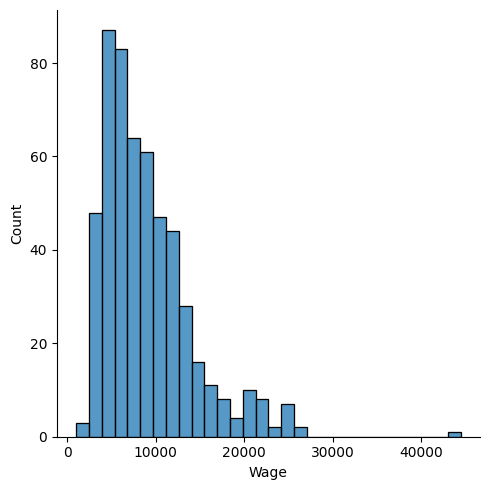

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'


# Data distribution of target variable. Here, we are checking is target is skewed. If it is skewed, then we need to tranform it by log or any other tranformation to make target normal.

# from matplotlib.pyplot import figure
# figsize=(2,2)
sns.displot(df['Wage'], kind='hist')

plt.tight_layout()
plt.show()

                Wage  Education  Experience       Age
Wage        1.000000   0.381922    0.087060  0.176967
Education   0.381922   1.000000   -0.352676 -0.150019
Experience  0.087060  -0.352676    1.000000  0.977961
Age         0.176967  -0.150019    0.977961  1.000000


<Axes: >

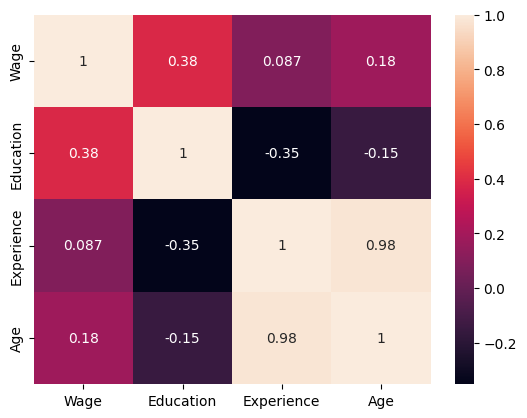

In [6]:
corr = df.corr()
# Print correlation matrix
print(corr)

# Plot correlation heatmap
sns.heatmap(corr, annot=True)